In [1]:
import os
os.chdir('../../../../..')

In [2]:
import polars as pl
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from kmedoids import KMedoids
from hdbscan import HDBSCAN

from src.helper_functions import create_chemiscope_viewer, average_numeric_by_cluster, plot_distance_matrix_projection
from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann, Wasserstein

INFO: Enabling RDKit 2025.09.4 jupyter extensions


In [3]:
qm9 = QM9Dataset(limit=1500, descriptors=["acsf"], sampling_strategy="stratified", stratify_by=["num_atoms", "gap"])
df = qm9.load()

2026-04-30 17:55:48.632 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-30 17:55:49.253 | INFO     | src.datasets:_sample_qm9_df:1072 - QM9 sampling complete: strategy=stratified, requested_limit=1651, returned_rows=1651.
2026-04-30 17:55:49.255 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=1651).
2026-04-30 17:55:49.258 | INFO     | src.features:compute_acsf_outputs:537 - Computing ACSF (rcut=6.0, normalize=True)...
2026-04-30 17:55:50.819 | SUCCESS  | src.datasets:add_acsf:1261 - Added ACSF embeddings and matrices.
2026-04-30 17:55:50.820 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['acsf_embedding', 'acsf_matrix']
2026-04-30 17:55:50.824 | INFO     | src.datasets:load:906 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=1500, returned_rows=1500, base_rows=1651.


# Riemann

In [4]:
riemann = Riemann()
dist_matrix_riemann = riemann.distance_matrix(df=df, descriptor='acsf')

2026-04-30 17:55:50.860 | INFO     | src.non_euclidean:_load_cached_distance_matrix:404 - Loading cached riemann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/riemann_qm9_n1500_acsf_affine-invariant_nopca.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_95873/3592406822.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_riemann, method='complete')


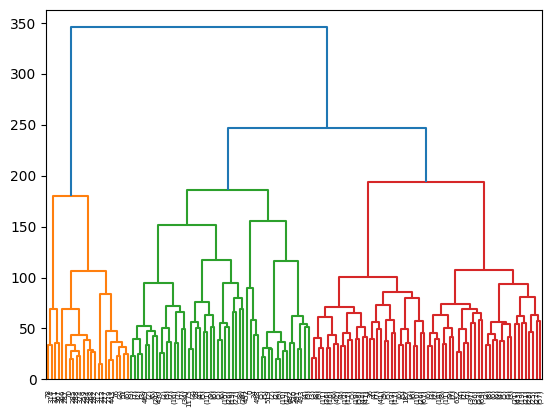

In [5]:
Z = linkage(dist_matrix_riemann, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=7, 
)

In [6]:
model_hier_riemann = AgglomerativeClustering(metric='precomputed', n_clusters=6, linkage='complete')
labels_hier_riemann = model_hier_riemann.fit_predict(dist_matrix_riemann)
print(np.unique(labels_hier_riemann, return_counts=True))
df = df.with_columns(labels_hier_riemann=labels_hier_riemann)

(array([0, 1, 2, 3, 4, 5]), array([618, 727, 140,   1,   1,  13]))


In [7]:
create_chemiscope_viewer(df, dist_matrix_riemann, labels_hier_riemann, 'MDS')

2026-04-30 17:55:52.383 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running MDS dimensionality reduction...
2026-04-30 17:55:52.385 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-30 17:56:43.935 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [8]:
average_numeric_by_cluster(df, "labels_hier_riemann")

shape: (6, 71)
┌─────────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier_riemann,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,618,0.710002,0.0,122.325243,0.496764,23.817152,1.001849,12.749715,8.736246,1.674757,0.017799,0.0,1.656958,19.601942,2.062069,2.597087,0.058764,0.123468,0.817769,0.487055,1.65534,6.644013,0.436893,0.846278,5.796117,6.425566,13.710356,1.262405,0.0,0.483819,0.001618,0.0,0.0,0.0,0.058252,0.182848,0.757282,0.0,1.984273,77.519466,-6.613969,0.732035,7.346044,1231.606032,4.542626,-10903.777656,-10903.537227,-10903.511507,-10904.696645,33.139419,-81.721193,-82.235749,-82.713545,-76.017769,3.324166,1.383927,1.135184,86.084142,1.779935,12.135922,13.710356,258,"""Acyclic""",12.135922,128,"""Acyclic""",12.135922,1,null,0.0
1,727,0.77104,0.0,123.587345,-0.240715,45.449794,0.805007,12.905257,8.801926,1.528198,0.151307,0.0,2.929849,17.894085,2.048809,2.397524,0.066313,0.252162,0.681526,1.235213,2.250344,6.401651,0.403026,1.357634,4.111417,6.381018,13.583219,1.260273,0.0,0.298487,0.048143,0.204952,0.264099,0.001376,0.034388,0.11967,0.486933,0.0,3.088717,73.634869,-6.532533,0.06579,6.598338,1197.066311,3.85941,-11429.337401,-11429.105083,-11429.079392,-11430.252074,31.393253,-73.61486,-74.053496,-74.475221,-68.514969,3.404907,1.358707,1.075372,71.526823,14.855571,13.617607,13.583219,331,"""Acyclic""",13.617607,132,"""C1CCCC1""",14.442916,1,null,0.0
2,140,0.749518,0.0,118.078571,-0.042857,29.257143,0.704044,12.847809,8.7,2.0,0.292857,0.021429,1.957143,18.357143,2.089509,1.635714,0.144388,0.215468,0.640145,1.042857,1.342857,6.871429,1.0,1.25,4.492857,6.314286,13.635714,1.26031,0.0,0.0,0.0,0.228571,0.0,0.0,0.0,0.0,0.0,0.0,2.824751,78.979714,-6.32171,0.548387,6.870175,1150.657717,4.016849,-10076.981027,-10076.759298,-10076.733587,-10077.876085,30.775093,-76.003399,-76.466556,-76.897615,-70.799131,3.618977,1.476669,1.168086,66.428571,27.857143,5.714286,13.635714,85,"""Acyclic""",5.714286,39,"""C1CCCC1""",15.714286,1,null,0.0
3,1,1.333333,0.0,116.0,0.0,55.0,0.895997,13.456277,8.0,1.0,1.0,1.0,5.0,9.0,2.0,0.0,0.0,1.0,0.0,0.0,4.0,3.0,0.0,3.0,0.0,4.0,12.0,1.307659,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.6909,48.849998,-8.043686,-3.292578,4.751108,786.550476,1.278201,-12914.304688,-12914.143555,-12914.118164,-12915.132812,21.32,-41.790054,-41.975445,-42.180973,-39.105133,4.22552,1.90258,1.31189,0.0,100.0,0.0,12.0,1,"""O=c1ccnno1""",100.0,1,"""CC1CCCCC1""",100.0,1,null,0.0
4,1,1.2,0.0,110.0,0.0,52.0,0.667909,12.854239,8.0,2.0,2.0,0.0,4.0,10.0,2.2,0.0,0.0,1.0,0.0,0.0,4.0,4.0,0.0,4.0,0.0,6.0,12.0,1.294391,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0003,52.84,-6.538896,-0.974168,5.564729,663.817078,1.739053,-11251.197266,-11251.06543,-11251.039062,-11251.987305,18.438,-48.691402,-48.944199,-49.175446,-45.685524,5.66163,2.39746,1.68425,0.0,100.0,0.0,12.0,1,"""c1nc2ocnc2o1""",100.0,1,"""C1CC2CCCC2C1""",100.0,1,null,0.0
5,13,0.92695,0.0,112.153846,0.076923,34.076923,0.975643,12.556962,8.307692,1.769231,0.0,0.0,2.076923,13.538462,2.061815,0.384

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


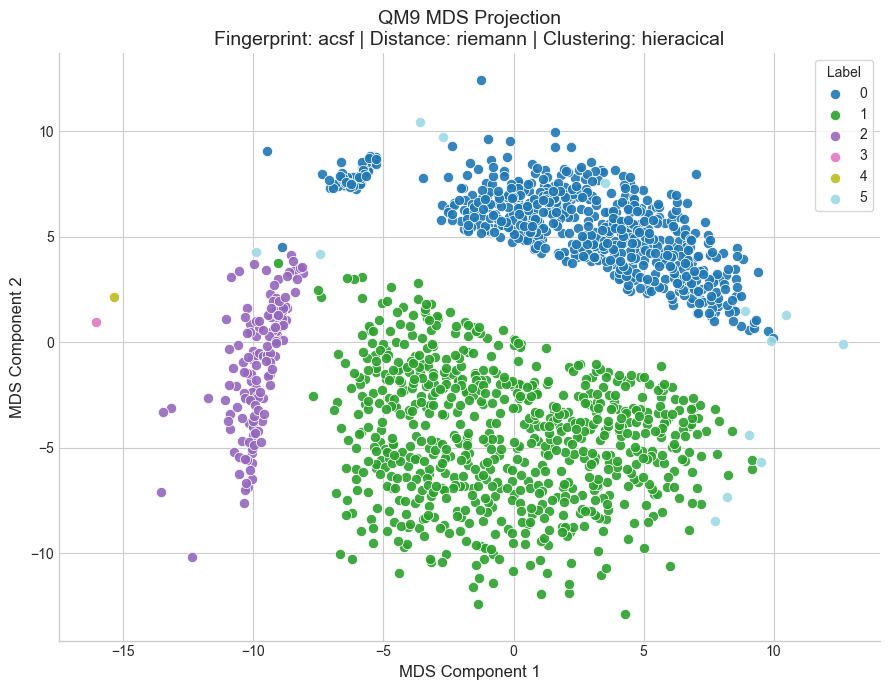

2026-04-30 17:57:18.893 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved MDS projection plot to figures/qm9/clustering/riemann/acsf/mds_hieracical_projection.png


{'coords': array([[-3.57675271, 10.43485603],
        [ 9.17483965, -6.0114949 ],
        [ 9.17618048, -5.5696991 ],
        ...,
        [ 2.86844839,  5.50237065],
        [ 1.13121823,  6.73328988],
        [ 6.93159028,  3.35292357]], shape=(1500, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/riemann/acsf/mds_hieracical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/riemann/acsf'),
 'clustering_method': 'hieracical'}

In [9]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix_riemann,
    fingerprint="acsf",
    distance_metric="riemann",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_riemann,
    clustering_method="hieracical",
)

# Grassmann

In [10]:
grassmann = Grassmann()
dist_matrix_grass = grassmann.distance_matrix(df=df, descriptor='acsf')

2026-04-30 17:57:19.331 | INFO     | src.non_euclidean:_load_cached_distance_matrix:404 - Loading cached grassmann distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/grassmann_qm9_n1500_acsf_k3_svd_norm.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_95873/3709222914.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_grass, method='complete')


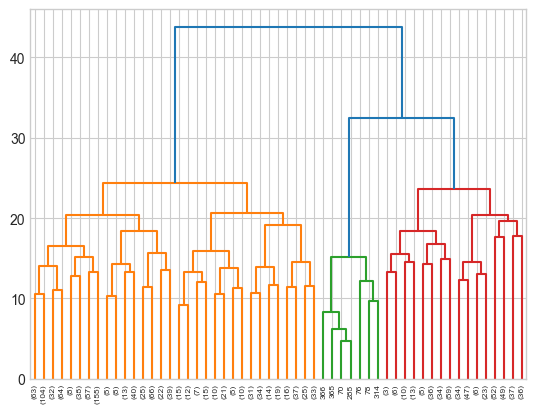

In [11]:
Z = linkage(dist_matrix_grass, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=5, 
)

In [12]:
model_hier_grass = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='complete')
labels_hier_grass = model_hier_grass.fit_predict(dist_matrix_grass)
print(np.unique(labels_hier_grass, return_counts=True))
df = df.with_columns(labels_hier_grass=labels_hier_grass)

(array([0, 1, 2]), array([ 409,   13, 1078]))


In [13]:
create_chemiscope_viewer(df, dist_matrix_grass, labels_hier_grass, 'ISOMAP')

2026-04-30 17:57:20.764 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running ISOMAP dimensionality reduction...
2026-04-30 17:57:20.767 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-30 17:57:39.723 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-30 17:57:39.732 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-30 17:57:39.818 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_ISOMAP_clustering.json
2026-04-30 17:57:39.853 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_ISOMAP_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - ISOMAP Clustering'}, settings={'map': {'x': {'property': 'ISOMAP_1'}, '…

In [14]:
average_numeric_by_cluster(df, "labels_hier_grass")

shape: (3, 72)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_hier_grass,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier_riemann,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,409,0.735744,0.0,121.515892,-0.141809,42.564792,0.757313,12.909249,8.721271,1.224939,0.259169,0.007335,2.794621,17.721271,2.020708,2.317848,0.109498,0.303413,0.587089,1.151589,2.095355,6.251834,0.723716,1.618582,3.584352,6.647922,12.838631,1.254364,0.0,0.156479,0.0489,0.273839,0.227384,0.002445,0.036675,0.129584,0.327628,0.0,2.99596,75.20802,-6.420463,0.025096,6.445539,1257.361976,3.817179,-11075.348129,-11075.112309,-11075.08661,-11076.273519,31.401638,-73.30109,-73.729334,-74.146465,-68.273245,3.869607,1.312306,1.021076,1.06846,56.479218,25.183374,18.337408,12.838631,177,"""Acyclic""",18.337408,72,"""C1CCCC1""",19.070905,1,null,0.0
1,13,1.029899,0.0,119.307692,0.0,66.923077,0.738881,12.952724,8.538462,1.076923,0.846154,0.076923,4.153846,12.384615,2.015385,1.384615,0.116667,0.811538,0.071795,1.538462,3.384615,4.538462,0.615385,3.461538,0.307692,5.923077,12.538462,1.271192,0.0,0.153846,0.615385,0.230769,0.076923,0.0,0.076923,0.076923,0.307692,0.0,2.774269,63.788461,-6.266364,-0.880393,5.38618,1036.943871,2.272659,-12087.067608,-12086.869366,-12086.843525,-12087.936223,26.615846,-56.699391,-56.972289,-57.260875,-53.067667,4.323379,1.527766,1.091173,1.769231,23.076923,76.923077,0.0,12.538462,10,"""c1cc[nH]c1""",23.076923,6,"""C1CCCC1""",53.846154,1,null,0.0
2,1078,0.746323,0.0,122.828386,0.171614,31.658627,0.925649,12.802803,8.777365,1.796846,0.044527,0.0,2.102968,18.997217,2.073013,2.426716,0.057731,0.148877,0.793392,0.794063,1.836735,6.653061,0.390538,0.93321,5.350649,6.293135,13.943414,1.26396,0.0,0.419295,0.007421,0.061224,0.090909,0.0,0.042672,0.138219,0.644712,0.0,2.459641,75.977894,-6.605049,0.518743,7.123845,1187.046537,4.288155,-11068.687512,-11068.45341,-11068.427704,-11069.597981,32.286927,-78.704788,-79.194245,-79.651075,-73.218631,3.242307,1.408797,1.146292,0.574212,85.343228,4.359926,10.296846,13.943414,466,"""Acyclic""",10.296846,177,"""C1CC1""",11.038961,1,null,0.0


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


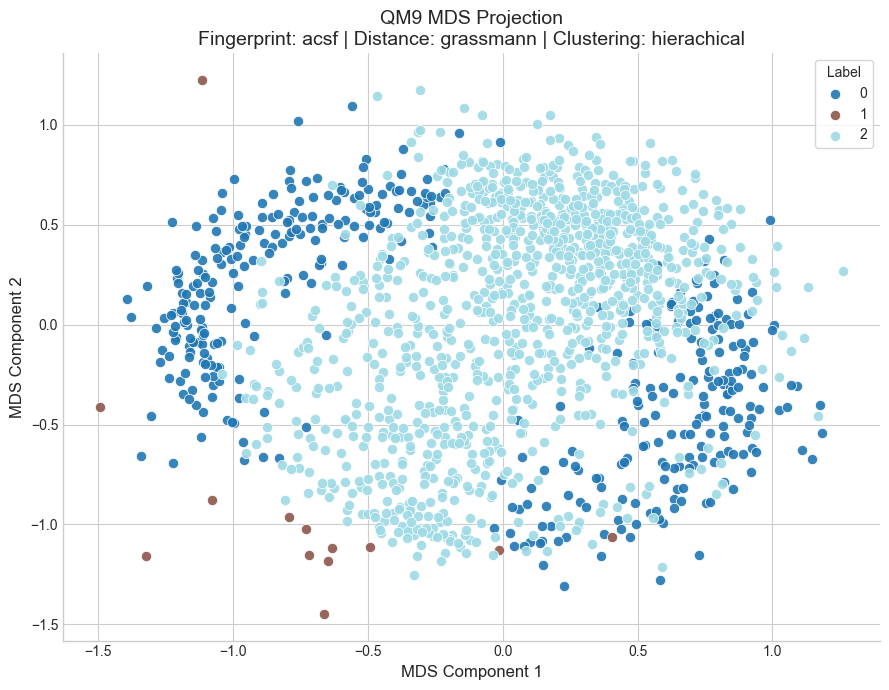

2026-04-30 17:58:05.101 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved MDS projection plot to figures/qm9/clustering/grassmann/acsf/mds_hierachical_projection.png


In [15]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix_grass,
    fingerprint="acsf",
    distance_metric="grassmann",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_grass,
    clustering_method="hierachical"
)

# Wasserstein

In [16]:
wasserstein = Wasserstein()
dist_matrix_wasser = wasserstein.distance_matrix(df=df, descriptor='acsf')

2026-04-30 17:58:05.170 | INFO     | src.non_euclidean:_load_cached_distance_matrix:404 - Loading cached wasserstein distance matrix from /Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/data/QM9/non_euclidean_cache/wasserstein_qm9_n1500_acsf_sqeuclidean.npy


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_95873/1791206022.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist_matrix_wasser, method='complete')


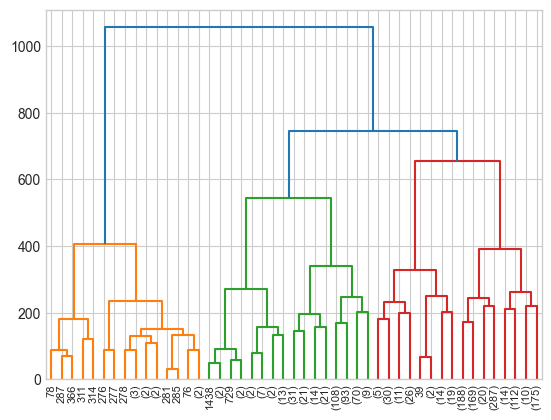

In [17]:
Z = linkage(dist_matrix_wasser, method='complete')

d = dendrogram(
    Z,
    truncate_mode='level',
    p=5, 
)

In [18]:
model_hier_wasser = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier_wasser = model_hier_wasser.fit_predict(dist_matrix_wasser)
print(np.unique(labels_hier_wasser, return_counts=True))
df = df.with_columns(labels_hier_wasser=labels_hier_wasser)

(array([0, 1, 2, 3]), array([541, 315,  68, 576]))


In [19]:
create_chemiscope_viewer(df, dist_matrix_wasser, labels_hier_wasser, 'MDS')

2026-04-30 17:58:06.244 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running MDS dimensionality reduction...
2026-04-30 17:58:06.245 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-04-30 17:58:38.327 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

In [20]:
average_numeric_by_cluster(df, "labels_hier_wasser")

shape: (4, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬───────────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_hier_wasser,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier_riemann,labels_hier_grass,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,541,0.821058,0.0,120.750462,-0.175601,38.650647,0.849574,12.803287,8.735675,1.853974,0.192237,0.003697,2.565619,16.757856,2.083279,1.650647,0.106007,0.287169,0.606824,0.937153,2.060998,6.197782,0.704251,1.67098,3.794824,6.243993,13.672828,1.268157,0.0,0.208872,0.040665,0.162662,0.140481,0.0,0.048059,0.182994,0.495379,0.0,2.811355,73.003882,-6.494286,-0.164918,6.329444,1131.597282,3.530889,-11110.319946,-11110.101322,-11110.075613,-11111.218357,29.771806,-70.948996,-71.35972,-71.753688,-66.157412,3.663247,1.460323,1.160001,0.955638,1.236599,70.425139,18.853974,10.720887,13.672828,290,"""Acyclic""",10.720887,131,"""C1CCCC1""",13.678373,1,null,0.0
1,315,0.674294,0.0,123.27619,0.746032,17.555556,0.948811,12.775945,8.844444,2.034921,0.006349,0.0,1.222222,21.498413,2.085632,2.612698,0.017372,0.073041,0.909587,0.552381,1.107937,7.638095,0.139683,0.571429,6.911111,6.28254,14.393651,1.261528,0.0,0.4,0.0,0.0,0.019048,0.0,0.012698,0.073016,0.444444,0.0,1.821866,81.931492,-6.52218,1.302052,7.824232,1214.918784,5.11629,-10493.540986,-10493.300398,-10493.274676,-10494.450181,34.169971,-88.057844,-88.641066,-89.164775,-81.81987,2.962686,1.420408,1.170921,0.266667,1.911111,93.333333,0.634921,6.031746,14.393651,182,"""C1CC1""",7.301587,93,"""C1CC1""",8.571429,1,null,0.0
2,68,0.901494,0.0,117.838235,-0.058824,63.455882,0.622009,12.992163,8.485294,0.985294,0.705882,0.029412,3.926471,13.647059,1.996751,1.455882,0.153466,0.652591,0.193943,1.441176,3.029412,4.911765,0.852941,2.794118,0.911765,6.323529,12.176471,1.258717,0.0,0.044118,0.191176,0.485294,0.235294,0.0,0.014706,0.044118,0.279412,0.0,3.365038,67.868676,-6.438294,-0.805897,5.632357,1103.607789,2.645243,-11484.397188,-11484.187148,-11484.161406,-11485.288301,27.674221,-59.864889,-60.169998,-60.487821,-55.933017,4.810989,1.488913,1.081108,1.544118,0.558824,20.588235,66.176471,13.235294,12.176471,37,"""Acyclic""",13.235294,14,"""C1CCCC1""",44.117647,1,null,0.0
3,576,0.696089,0.0,124.112847,-0.015625,37.590278,0.896536,12.873649,8.769097,1.286458,0.019097,0.0,2.472222,19.309028,2.027033,3.067708,0.061245,0.125682,0.813073,0.986111,2.102431,6.414931,0.420139,0.762153,5.114583,6.585069,13.34375,1.255316,0.0,0.479167,0.001736,0.104167,0.163194,0.001736,0.053819,0.135417,0.704861,0.0,2.759119,75.650885,-6.635374,0.50677,7.142167,1280.275363,4.360562,-11322.755019,-11322.506677,-11322.480988,-11323.689446,33.407375,-78.764859,-79.250399,-79.71412,-73.221279,3.284498,1.278765,1.037488,0.647569,1.493056,80.729167,1.909722,17.361111,13.34375,228,"""Acyclic""",17.361111,83,"""C1CC1""",17.361111,1,null,0.0


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


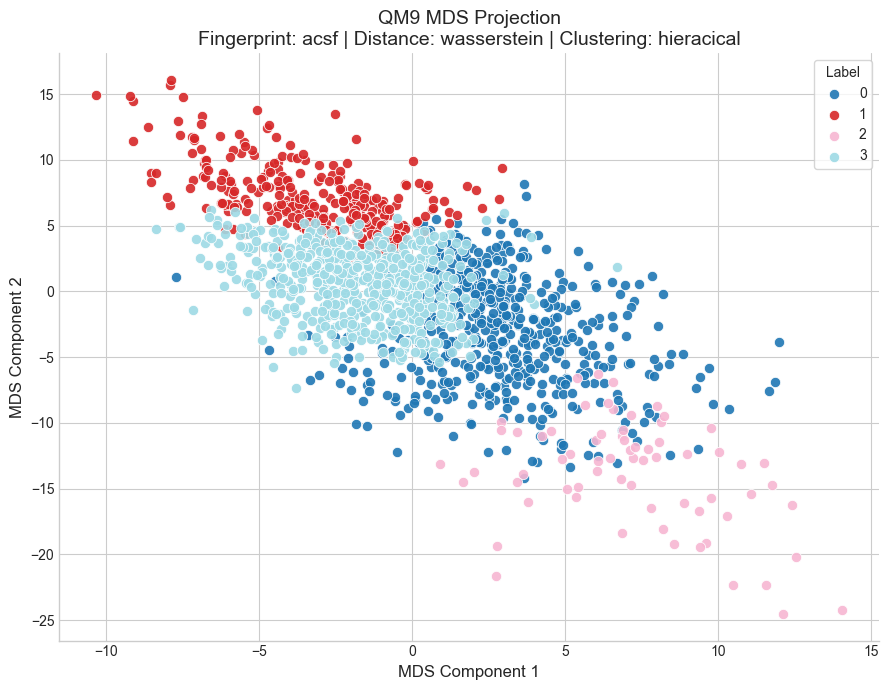

2026-04-30 17:58:55.559 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved MDS projection plot to figures/qm9/clustering/wasserstein/acsf/mds_hieracical_projection.png


{'coords': array([[  7.95649849, -12.57491719],
        [  3.66469473, -14.22090725],
        [ -1.4811221 , -10.27308134],
        ...,
        [ -3.89313824,   0.14996652],
        [ -5.86287766,   4.72562094],
        [ -4.46717809,  -1.70046326]], shape=(1500, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/wasserstein/acsf/mds_hieracical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/wasserstein/acsf'),
 'clustering_method': 'hieracical'}

In [21]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix_wasser,
    fingerprint="acsf",
    distance_metric="wasserstein",
    projection_method="MDS",
    dataset_name="qm9",
    labels=labels_hier_wasser,
    clustering_method="hieracical"
)